In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
targets = pd.read_csv("tess_id_sector_exptime_G16d20_all_filtered_UPDATED_SEC_UTD.csv")


stars = targets.groupby("ID").agg(
    SPOC_Avail=("SPOC_Avail", "max"),
    FFI_Avail=("FFI_Avail", "max"),
    n_rows=("ID", "size")
).reset_index()


catalog = pd.read_csv("TESS_M=0.4_RP=15.csv")
limited = pd.read_csv("tess_id_sector_exptime_G16d20_all_filtered_UPDATED_SEC_UTD.csv")
catalog["source_id"] = catalog["source_id"].astype(str).str.replace(".0","",regex=False)
limited["ID"] = limited["ID"].astype(str).str.replace(".0","",regex=False)

In [6]:
cols = [
    "source_id",
    "phot_g_mean_mag",
    "phot_rp_mean_mag",
    "parallax"
]

merged = limited.merge(
    catalog[cols],
    left_on="ID",
    right_on="source_id",
    how="left"
)

In [7]:
merged["distance_pc"] = 1000 / merged["parallax"]
merged["color"] = merged["phot_g_mean_mag"] - merged["phot_rp_mean_mag"]

stars = merged.groupby("ID").agg(
    SPOC_Avail=("SPOC_Avail","max"),
    FFI_Avail=("FFI_Avail","max"),
    phot_g_mean_mag=("phot_g_mean_mag","first"),
    phot_rp_mean_mag=("phot_rp_mean_mag","first"),
    parallax=("parallax","first"),
    distance_pc=("distance_pc","first"),
    color=("color","first")
).reset_index()

In [8]:
merged = limited.merge(
    catalog[["source_id","phot_g_mean_mag","phot_rp_mean_mag","parallax"]],
    left_on="ID",
    right_on="source_id",
    how="left"
)

merged["distance_pc"] = 1000 / merged["parallax"]
merged["color"] = merged["phot_g_mean_mag"] - merged["phot_rp_mean_mag"]

merged.to_csv(
    "limited_sample_with_stellar_properties.csv",
    index=False
)

stars = merged.groupby("ID").agg(
    SPOC_Avail=("SPOC_Avail","max"),
    phot_g_mean_mag=("phot_g_mean_mag","first"),
    phot_rp_mean_mag=("phot_rp_mean_mag","first"),
    parallax=("parallax","first"),
    distance_pc=("distance_pc","first"),
    color=("color","first")
).reset_index()

stars.to_csv(
    "unique_stars_with_spoc_properties.csv",
    index=False
)


In [9]:
catalog = pd.read_csv("TESS_M=0.4_RP=15.csv")
limited = pd.read_csv("tess_id_sector_exptime_G16d20_all_filtered_UPDATED_SEC_UTD.csv")

catalog["source_id"] = catalog["source_id"].astype(str)
limited["ID"] = limited["ID"].astype(str)

radius_cols = [
    "source_id",
    "radius",
    "radius+",
    "radius-"
]

merged = limited.merge(
    catalog[radius_cols],
    left_on="ID",
    right_on="source_id",
    how="left"
)

merged.to_csv(
    "limited_sample_with_radius.csv",
    index=False
)


In [10]:
stars = merged.groupby("ID").agg(
    SPOC_Avail=("SPOC_Avail","max"),
    radius=("radius","first"),
    radius_plus=("radius+","first"),
    radius_minus=("radius-","first")
).reset_index()

catalog = pd.read_csv("TESS_M=0.4_RP=15.csv")
limited = pd.read_csv("tess_id_sector_exptime_G16d20_all_filtered_UPDATED_SEC_UTD.csv")

catalog["source_id"] = catalog["source_id"].astype(str).str.replace(".0","",regex=False)
limited["ID"] = limited["ID"].astype(str).str.replace(".0","",regex=False)

cols = [
    "source_id",
    "phot_g_mean_mag",
    "phot_rp_mean_mag",
    "parallax",
    "radius",
    "radius+",
    "radius-"
]

merged = limited.merge(
    catalog[cols],
    left_on="ID",
    right_on="source_id",
    how="left"
)

merged["distance_pc"] = 1000 / merged["parallax"]
merged["color"] = merged["phot_g_mean_mag"] - merged["phot_rp_mean_mag"]

merged.to_csv(
    "limited_sample_with_stellar_properties.csv",
    index=False
)

stars = merged.groupby("ID").agg(
    SPOC_Avail=("SPOC_Avail","max"),
    FFI_Avail=("FFI_Avail","max"),
    phot_g_mean_mag=("phot_g_mean_mag","first"),
    phot_rp_mean_mag=("phot_rp_mean_mag","first"),
    parallax=("parallax","first"),
    distance_pc=("distance_pc","first"),
    color=("color","first"),
    radius=("radius","first"),
    radius_plus=("radius+","first"),
    radius_minus=("radius-","first")
).reset_index()

stars.to_csv(
    "unique_stars_with_spoc_properties.csv",
    index=False
)

spoc = stars[stars["SPOC_Avail"] == True]
non_spoc = stars[stars["SPOC_Avail"] == False]

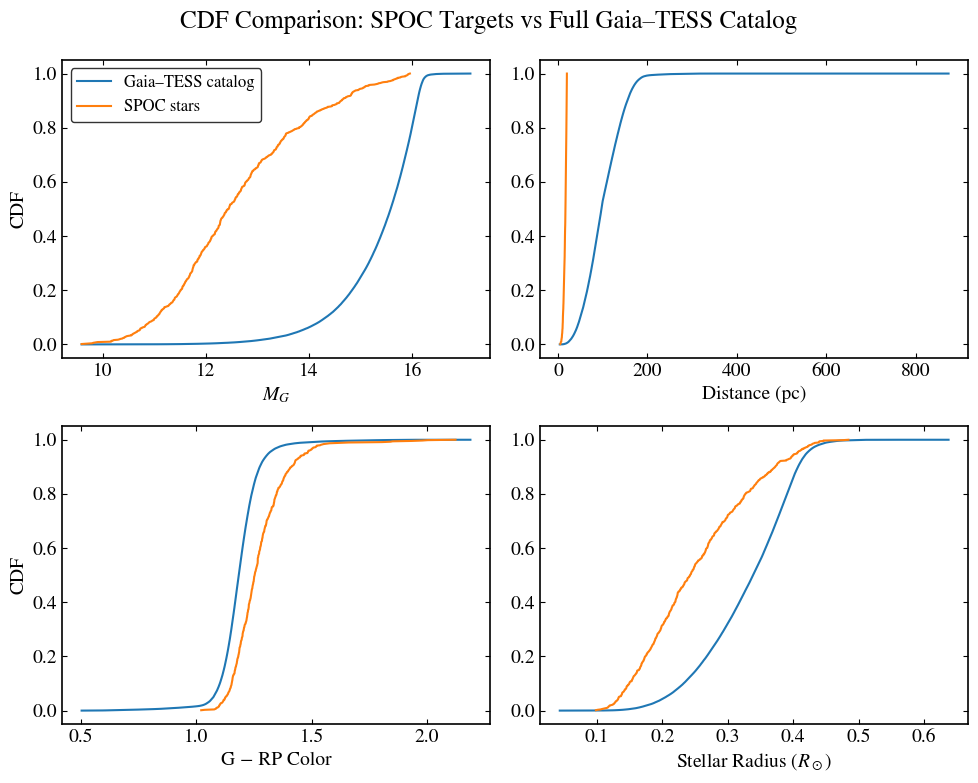

In [ ]:
# How do stars processed by the SPOC pipeline differ from the original Gaia–TESS stellar population?

# compare the culmulative distributions of the SPOC targets and full sample for each specific stellar parameter
# histograms were useful for a visual comparison, but CDFs are better for comparing distributions
# CDFs become useful here because they show the entire distributions compare, not just the counts in specific bins. 
# for any given x, CDF shows: F(x) = P(X <= x), the fraction of stars with parameter value less than or equal to x (some give value).
# example: if the SPOC CDF rises quicker in magntiude, it means SPOC stars are generally brighter (lower magnitude) than the full sample.
# if the distance CDF shifts to the left, SPOC stars are generally closer 
# if the radius CDF shifts to the left, SPOC stars are generally smaller.

# initial interpretation:
# Magnitude: If the SPOC CDF rises earlier than the full sample, it would suggest that the SPOC targers are generally brighter
# Distance: If the SPOC CDF curve moves to the left, it would suggest that the targets are generally closer than the full sample
# Color: If the SPOC CDF curve shifts to the right, it would suggest that the targets are generally redder (higher G-RP color) than the full sample
# Radius: If the SPOC CDF curve shifts to the left, it would suggest that the targets are generally smaller than the full sample

#CDFs benefit here by showing that systematic shifts in the distributions that histograms might not clearly show due to binning choices
# also, CDFs allow us to easily compare the entire distribution and identify differences in the tails, which can be important for 
# understanding selection effects in the SPOC targets. 
# important to run before the KS test to visually inspect the distributions and understand any differences before quantifying 
# them with a statistical test.

# Theoretically, CDFs are defined for a known probability distribution, but here, we can use the empirical CDFs (eCDF) to compare
# the distributions of the SPOC targets and the full sample
# A eCDF compares the cumulative distribution of the observed data to a theoretical distribution, but in this case, we are comparing 
# two empirical distributions (SPOC vs full sample), so we can directly compare their eCDFs to understand how the SPOC targets differ 
# from the overall population in terms of magnitude, distance, color, and radius.
# A eCDF is computed directly from the data when we don't know the underlying distribution, which is the case here since we are working 
# with observed stellar properties that may not follow a simple theoretical distribution.

# RESULTS
# How do the stars processed by the SPOC pipeline differ from the original Gaia–TESS stellar population?
# The SPOC pipeline is biased towards brighter, closer, redder, and smaller stars compared to the full Gaia–TESS catalog.
# Magnitude: The SPOC CDF rises earlier and to the left compared to the full sample, indicating that the SPOC targets are generally
# brighter (lower magnitude) than the full sample. 
# Why? The SPOC pipeline prioritizes brighter stars for high-precision photometry, transit detections require high photometric precision, 
# high SNR for transit detection, and brighter stars provide better SNR, so the pipeline will favor them in the target selection process.
# Distance: SPOC CDF shifts to the left and rises earlier than the full sample, indicating that the SPOC targets are generally closer than the 
# full sample. But we also affected this bias by limiting our sample to stars with G < 16 and distance < 200 pc, so we are already pre-selecting
# for closer stars, but even within this limited sample, the SPOC targets are still biased towards the closer end of the distribution.
# SPOC stars are closer, this is expected since nearby stars are brighter and provide better SNR 
# Color: The SPOC CDF shifts to the right, indicating that the targets are generally redder (higher G-RP color) than the full sample.
# This shows SPOC stars are generally redder stars which means they are cooler, this is expected since cooler stars (like M dwarfs) are smaller,
# and smaller stars provide better transit depth for a given planet size, making them more favorable for transit detection.
# Radius: The SPOC CDF shifts to the left, showing that the targets are generally smaller than the full sample. This in turn is what
# transit surveys like TESS prioritize since transit depth = (Rp/Rs)^2, smaller stars provide deeper transits for a given planet size, 
# making them more favorable for transit detection, smaller star leads to a deeper transit for a given planet size and the detection efficiency
# improves overall.
# SPOC PIPELINE IS BIASED TOWARDS BRIGHTER, CLOSER, REDDER, AND SMALLER STARS COMPARED TO THE FULL GAIA–TESS CATALOG.
# This is the expended bias you would expect from a transit survey like TESS

plt.rcParams.update({
    "font.family": "STIXGeneral",
    "mathtext.fontset": "stix",
    "font.size": 14,
    "axes.linewidth": 1.2,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True
    })


# derived quantities for full catalog
catalog["distance_pc"] = 1000 / catalog["parallax"]
catalog["color"] = catalog["phot_g_mean_mag"] - catalog["phot_rp_mean_mag"]

# derived quantities for limited sample
merged["distance_pc"] = 1000 / merged["parallax"]
merged["color"] = merged["phot_g_mean_mag"] - merged["phot_rp_mean_mag"]


fig, axs = plt.subplots(2, 2, figsize=(10, 8))

# magnitude CDF
full_mag = np.sort(catalog["phot_g_mean_mag"].dropna())
spoc_mag = np.sort(spoc["phot_g_mean_mag"].dropna())

# F(x) = P(X <= x) = rank of x / total number of valuesl; i / n for the ith value in the sorted array
# CDF is calculated as the rank of each value divided by the total number of values
# +1 is needed in CDF calculation to ensure that the CDF reaches 1 at the maximum value
cdf_full = np.arange(1, len(full_mag) + 1) / len(full_mag)
cdf_spoc = np.arange(1, len(spoc_mag) + 1) / len(spoc_mag)
    
axs[0,0].plot(full_mag, cdf_full, label="Gaia–TESS catalog")
axs[0,0].plot(spoc_mag, cdf_spoc, label="SPOC stars")
axs[0,0].set_xlabel("$M_G$")
axs[0,0].set_ylabel("CDF")
#axs[0,0].set_title("Magnitude")
axs[0,0].legend(edgecolor="black", fontsize=12)

# distance CDF
full_dist = np.sort(catalog["distance_pc"].dropna())
spoc_dist = np.sort(spoc["distance_pc"].dropna())

cdf_full = np.arange(1, len(full_dist) + 1) / len(full_dist)
cdf_spoc = np.arange(1, len(spoc_dist) + 1) / len(spoc_dist)

axs[0,1].plot(full_dist, cdf_full, label="Full catalog")
axs[0,1].plot(spoc_dist, cdf_spoc, label="SPOC stars")
axs[0,1].set_xlabel("Distance (pc)")
#axs[0,1].set_ylabel("CDF")
#axs[0,1].set_title("Distance")
#axs[0,1].set_xlim(0,200)

# color CDF
full_color = np.sort(catalog["color"].dropna())
spoc_color = np.sort(spoc["color"].dropna())

cdf_full = np.arange(1, len(full_color) + 1) / len(full_color)
cdf_spoc = np.arange(1, len(spoc_color) + 1) / len(spoc_color)

axs[1,0].plot(full_color, cdf_full, label="Full catalog")
axs[1,0].plot(spoc_color, cdf_spoc, label="SPOC stars")
axs[1,0].set_xlabel("G − RP Color")
axs[1,0].set_ylabel("CDF")
#axs[1,0].set_title("Color")

# radius CDF
full_radius = np.sort(catalog["radius"].dropna())
spoc_radius = np.sort(spoc["radius"].dropna())

cdf_full = np.arange(1, len(full_radius) + 1) / len(full_radius)
cdf_spoc = np.arange(1, len(spoc_radius) + 1) / len(spoc_radius)

axs[1,1].plot(full_radius, cdf_full, label="Full catalog")
axs[1,1].plot(spoc_radius, cdf_spoc, label="SPOC stars")
axs[1,1].set_xlabel("Stellar Radius ($R_\\odot$)")
#axs[1,1].set_ylabel("CDF")
#axs[1,1].set_title("Stellar Radius")

fig.suptitle("CDF Comparison: SPOC Targets vs Full Gaia–TESS Catalog", fontsize=18)

plt.tight_layout()
plt.show()

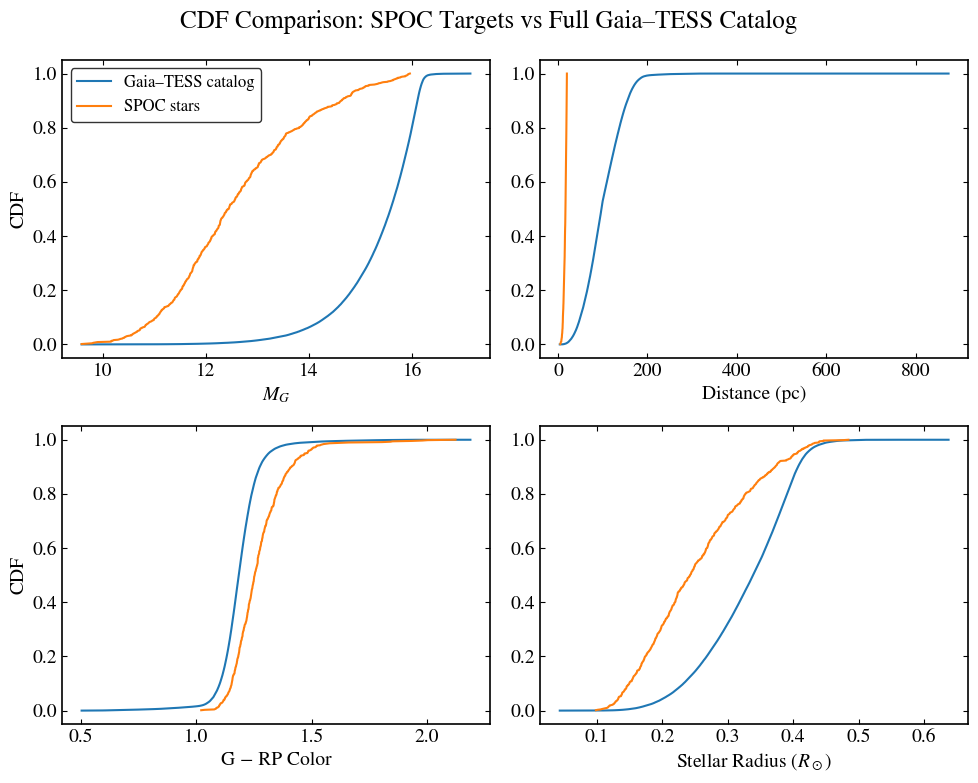

In [12]:
# only required stuff to run 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# load the full Gaia–TESS catalog
catalog = pd.read_csv("TESS_M=0.4_RP=15.csv")

# load the already-saved unique-star merged file
stars = pd.read_csv("unique_stars_with_spoc_properties.csv")

# make sure IDs are clean if needed
#catalog["source_id"] = catalog["source_id"].astype(str)

# make SPOC column boolean
stars["SPOC_Avail"] = (
    stars["SPOC_Avail"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map({"true": True, "false": False})
    #.fillna(False)
)

# subset of SPOC stars
spoc = stars[stars["SPOC_Avail"]]

# derived quantities for full catalog
catalog["distance_pc"] = 1000 / catalog["parallax"]
catalog["color"] = catalog["phot_g_mean_mag"] - catalog["phot_rp_mean_mag"]

plt.rcParams.update({
    "font.family": "STIXGeneral",
    "mathtext.fontset": "stix",
    "font.size": 14,
    "axes.linewidth": 1.2,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True
})

fig, axs = plt.subplots(2, 2, figsize=(10, 8))

# magnitude CDF
full_mag = np.sort(catalog["phot_g_mean_mag"])#.dropna())
spoc_mag = np.sort(spoc["phot_g_mean_mag"])#.dropna())

cdf_full = np.arange(1, len(full_mag) + 1) / len(full_mag)
cdf_spoc = np.arange(1, len(spoc_mag) + 1) / len(spoc_mag)

axs[0,0].plot(full_mag, cdf_full, label="Gaia–TESS catalog")
axs[0,0].plot(spoc_mag, cdf_spoc, label="SPOC stars")
axs[0,0].set_xlabel("$M_G$")
axs[0,0].set_ylabel("CDF")
axs[0,0].legend(edgecolor="black", fontsize=12)

# distance CDF
full_dist = np.sort(catalog["distance_pc"].dropna())
spoc_dist = np.sort(spoc["distance_pc"].dropna())

cdf_full = np.arange(1, len(full_dist) + 1) / len(full_dist)
cdf_spoc = np.arange(1, len(spoc_dist) + 1) / len(spoc_dist)

axs[0,1].plot(full_dist, cdf_full, label="Gaia–TESS catalog")
axs[0,1].plot(spoc_dist, cdf_spoc, label="SPOC stars")
axs[0,1].set_xlabel("Distance (pc)")

# color CDF
full_color = np.sort(catalog["color"].dropna())
spoc_color = np.sort(spoc["color"].dropna())

cdf_full = np.arange(1, len(full_color) + 1) / len(full_color)
cdf_spoc = np.arange(1, len(spoc_color) + 1) / len(spoc_color)

axs[1,0].plot(full_color, cdf_full, label="Gaia–TESS catalog")
axs[1,0].plot(spoc_color, cdf_spoc, label="SPOC stars")
axs[1,0].set_xlabel("G − RP Color")
axs[1,0].set_ylabel("CDF")

# radius CDF
full_radius = np.sort(catalog["radius"].dropna())
spoc_radius = np.sort(spoc["radius"].dropna())

cdf_full = np.arange(1, len(full_radius) + 1) / len(full_radius)
cdf_spoc = np.arange(1, len(spoc_radius) + 1) / len(spoc_radius)

axs[1,1].plot(full_radius, cdf_full, label="Gaia–TESS catalog")
axs[1,1].plot(spoc_radius, cdf_spoc, label="SPOC stars")
axs[1,1].set_xlabel("Stellar Radius ($R_\\odot$)")

fig.suptitle("CDF Comparison: SPOC Targets vs Full Gaia–TESS Catalog", fontsize=18)

plt.tight_layout()
plt.show()